<a href="https://colab.research.google.com/github/onehemanth/mtech_thesis/blob/main/comparison_geoid_models_data_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

## Data loading

Load the two CSV files into pandas DataFrames.


In [ ]:


try:
    df_comparison = pd.read_csv('comparison_gravity_anomalies.csv')
    df_stats = pd.read_csv('stats_comparison_gravity_anomalies.csv')
    display(df_comparison.head())
    display(df_stats.head())
except FileNotFoundError:
    print("Error: One or both of the CSV files were not found.")
except pd.errors.ParserError:
    print("Error: There was an issue parsing one or both of the CSV files.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

,Sl No,LAT,LONG,HT,G,gravity_anomaly_fa,EGM2008_GAF,EIGEN-6C4_GAF,GECO_GAF,XGM2019e_GAF,...,EGM2008_GAF_Diff,EIGEN-6C4_GAF_Diff,GECO_GAF_Diff,XGM2019e_GAF_Diff,SGG-UGM-2_GAF_Diff,GGM05S_GAF_Diff,GO_CONS_GCF_2_DIR_R6_GAF_Diff,GO_CONS_GCF_2_TIM_R6e_GAF_Diff,GOCO06s_GAF_Diff,ITSG-Grace2018s_GAF_Diff
0,1,26.21732,81.2503,109.7,978.93751,-69.834792,-49.088724,-45.210906,-46.755801,-44.166377,...,-20.746068,-24.623886,-23.078991,-25.668415,-25.800917,-17.694072,-31.995938,-30.403521,-30.913700,-19.820885
1,2,27.90667,78.0733,186.5,979.06166,-45.540473,-48.458801,-44.381131,-44.069740,-47.988972,...,2.918328,-1.159342,-1.470734,2.448498,0.835431,-18.280703,-14.528225,-15.155356,-15.234018,0.172102
2,3,28.02611,79.1281,168.0,979.04985,-71.993843,-70.598804,-71.283094,-70.480791,-63.682774,...,-1.395039,-0.710750,-1.513052,-8.311069,-1.900183,4.202417,-3.124118,-3.839601,-4.952145,8.185337
3,4,28.65139,79.8253,185.9,979.02685,-136.644475,-138.119611,-132.584575,-133.715493,-129.849283,...,1.475136,-4.059900,-2.928982,-6.795192,-4.782728,13.922139,-6.344179,-6.074756,-5.595676,-5.120351
4,5,26.25032,81.3803,110.3,978.95940,-50.121867,-54.370619,-49.865869,-51.401437,-48.018811,...,4.248752,-0.255998,1.279570,-2.103056,-1.182068,9.001454,-8.930453,-7.012642,-7.379172,3.288391


,GGMS,EGM2008,EIGEN-6C4,GECO,XGM2019e,SGG-UGM-2,GGM05S,GO_CONS_GCF_2_DIR_R6,GO_CONS_GCF_2_TIM_R6e,GOCO06s,ITSG-Grace2018s
0,Minimum,-151.916914,-147.234280,-139.917101,-153.491422,-150.418306,-320.293636,-364.364129,-363.556942,-363.947945,-348.840499
1,Maximum,181.296435,183.450356,192.315964,182.705377,185.288419,174.062881,154.901010,154.177771,153.352722,171.309367
2,Mean,-3.349194,-2.972971,-3.743794,-4.042806,-3.066003,-13.818653,-11.939432,-12.005405,-11.956206,-13.837402
3,Median,-0.469186,-0.970372,-0.984568,-1.161647,-0.790980,-1.215619,-1.669449,-1.652596,-1.651570,-1.035108
4,S.D,21.115507,20.510676,20.792083,22.505500,20.628197,51.743537,51.650328,51.529821,51.571874,53.171637


## Data exploration

Explore the structure and content of the loaded datasets to understand their characteristics and identify relevant columns for subsequent analysis and visualization.


In [ ]:
# Examine the shape of both DataFrames
print("Shape of df_comparison:", df_comparison.shape)
print("Shape of df_stats:", df_stats.shape)

# Inspect the column names
print("\nColumns of df_comparison:", df_comparison.columns.tolist())
print("\nColumns of df_stats:", df_stats.columns.tolist())

# Check data types
print("\nData types of df_comparison:\n", df_comparison.dtypes)
print("\nData types of df_stats:\n", df_stats.dtypes)

# Summarize missing values
print("\nMissing values in df_comparison:\n", df_comparison.isnull().sum())
print("\nMissing values in df_stats:\n", df_stats.isnull().sum())

Shape of df_comparison: (5500, 26)
Shape of df_stats: (9, 11)

Columns of df_comparison: ['Sl No', 'LAT', 'LONG', 'HT', 'G', 'gravity_anomaly_fa', 'EGM2008_GAF', 'EIGEN-6C4_GAF', 'GECO_GAF', 'XGM2019e_GAF', 'SGG-UGM-2_GAF', 'GGM05S_GAF', 'GO_CONS_GCF_2_DIR_R6_GAF', 'GO_CONS_GCF_2_TIM_R6e_GAF', 'GOCO06s_GAF', 'ITSG-Grace2018s_GAF', 'EGM2008_GAF_Diff', 'EIGEN-6C4_GAF_Diff', 'GECO_GAF_Diff', 'XGM2019e_GAF_Diff', 'SGG-UGM-2_GAF_Diff', 'GGM05S_GAF_Diff', 'GO_CONS_GCF_2_DIR_R6_GAF_Diff', 'GO_CONS_GCF_2_TIM_R6e_GAF_Diff', 'GOCO06s_GAF_Diff', 'ITSG-Grace2018s_GAF_Diff']

Columns of df_stats: ['GGMS', 'EGM2008', 'EIGEN-6C4', 'GECO', 'XGM2019e', 'SGG-UGM-2', 'GGM05S', 'GO_CONS_GCF_2_DIR_R6', 'GO_CONS_GCF_2_TIM_R6e', 'GOCO06s', 'ITSG-Grace2018s']

Data types of df_comparison:
 Sl No                               int64
LAT                               float64
LONG                              float64
HT                                float64
G                                 float64
gravity_anoma

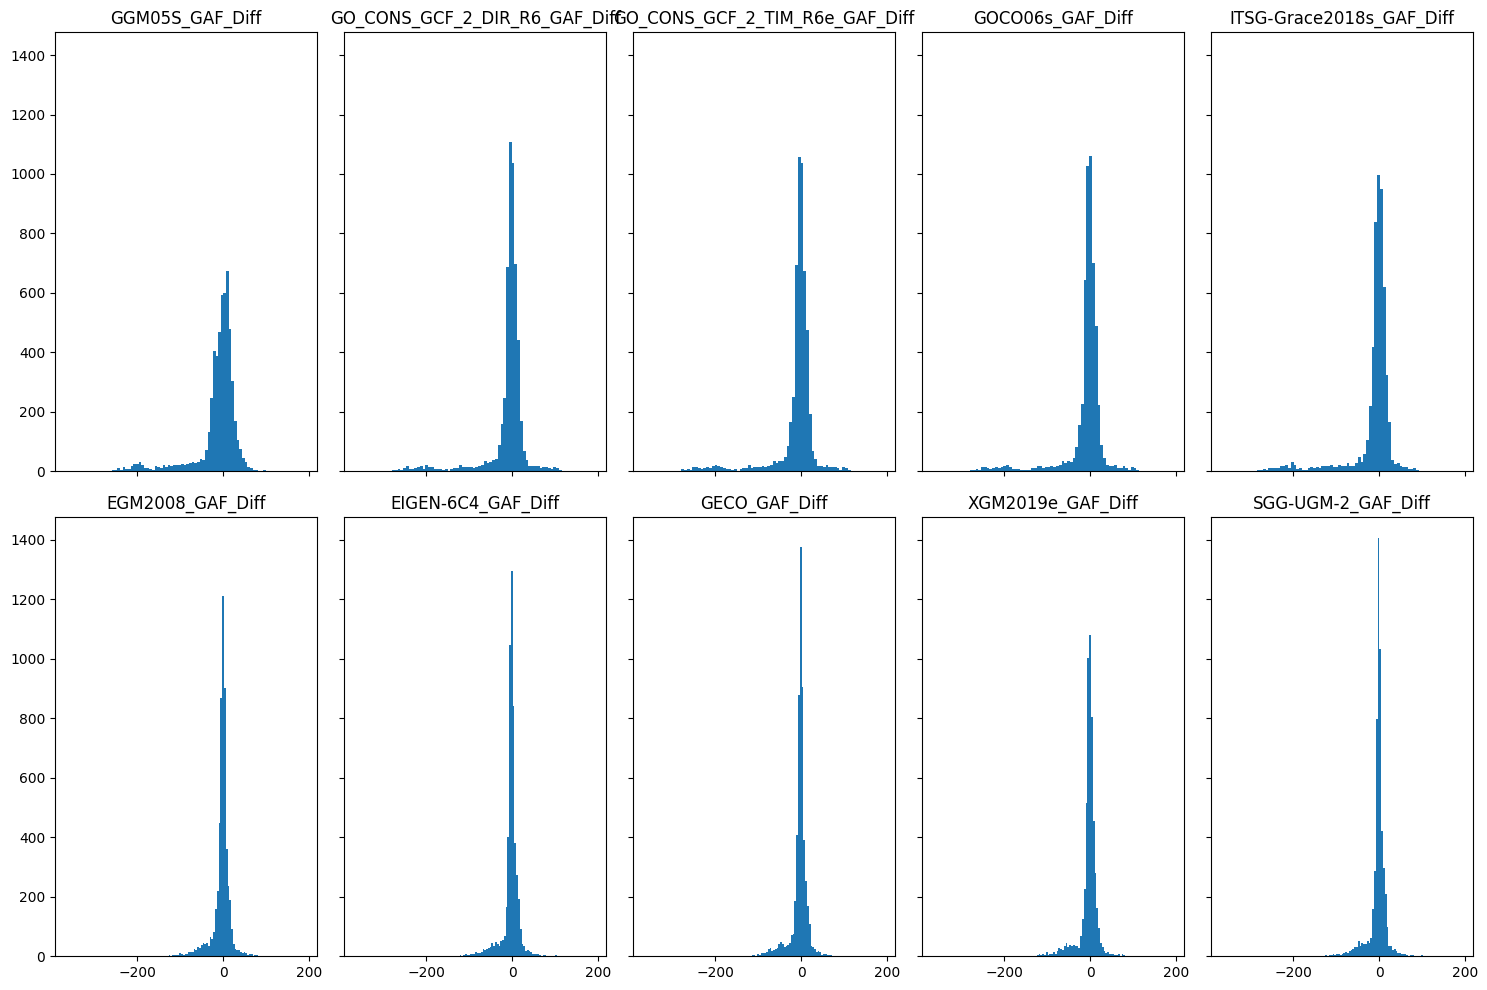

In [ ]:
# Define columns for the first subplot (last 5 columns)
last_5_cols = df_comparison.columns[-5:]

# Define columns for the second subplot (previous 5 columns)
previous_5_cols = df_comparison.columns[-10:-5]

# Create a figure and axes with shared y and x axes
fig, axes = plt.subplots(2, 5, figsize=(15, 10), sharey=True, sharex=True)

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterate through the first 5 columns and plot on the first row
for i, col in enumerate(last_5_cols):
    axes[i].hist(df_comparison[col], bins=80)
    axes[i].set_title(col)

# Iterate through the previous 5 columns and plot on the second row
for i, col in enumerate(previous_5_cols):
    axes[i + 5].hist(df_comparison[col], bins=80)
    axes[i + 5].set_title(col)

plt.tight_layout()
plt.show()

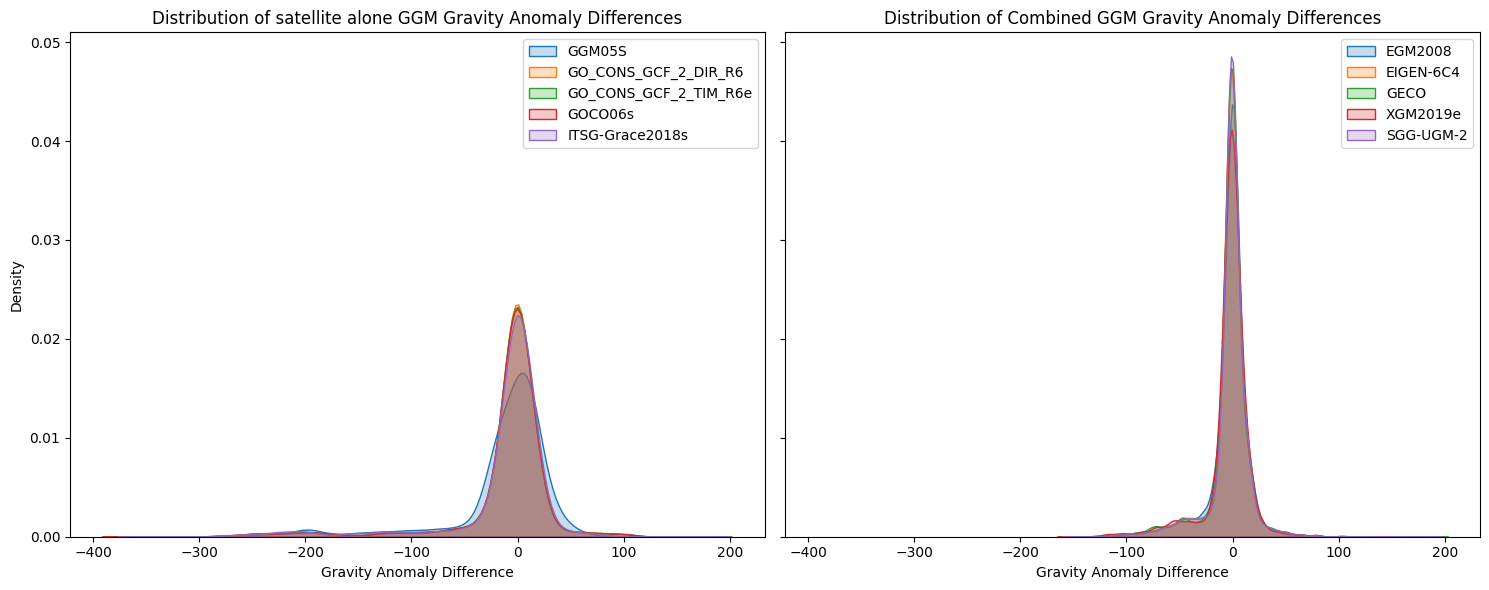

In [ ]:
# Create a figure and axes with shared y and x axes
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True, sharex=True)

# Iterate through the first 5 columns and plot on the first subplot
for i, col in enumerate(last_5_cols):
    sns.kdeplot(df_comparison[col], label=col.replace("_GAF_Diff", ""), fill=True, ax=axes[0])

# Set title and labels for the first subplot
axes[0].set_xlabel("Gravity Anomaly Difference")
axes[0].set_ylabel("Density")
axes[0].set_title("Distribution of satellite alone GGM Gravity Anomaly Differences")
axes[0].legend()

# Iterate through the previous 5 columns and plot on the second subplot
for i, col in enumerate(previous_5_cols):
    sns.kdeplot(df_comparison[col], label=col.replace("_GAF_Diff", ""), fill=True, ax=axes[1])

# Set title and labels for the second subplot
axes[1].set_xlabel("Gravity Anomaly Difference")
axes[1].set_ylabel("Density")
axes[1].set_title("Distribution of Combined GGM Gravity Anomaly Differences")
axes[1].legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

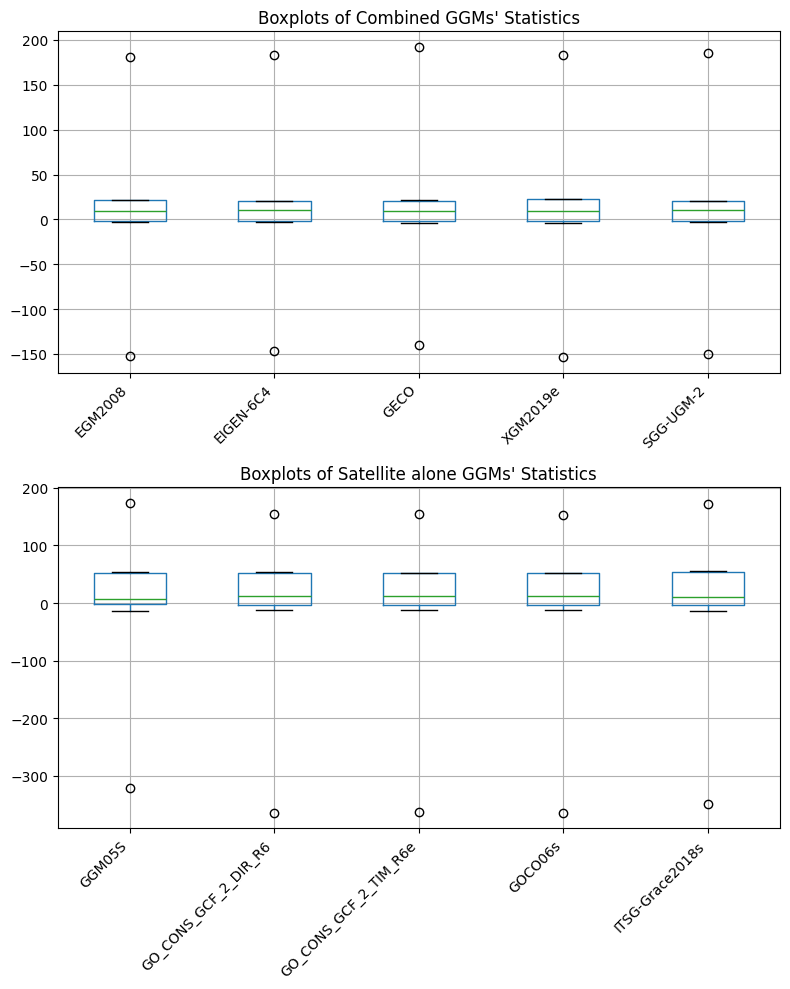

In [ ]:
import matplotlib.pyplot as plt

# Define columns for the first subplot (first 5 columns)
first_5_cols = ['EGM2008', 'EIGEN-6C4', 'GECO', 'XGM2019e', 'SGG-UGM-2']

# Define columns for the second subplot (remaining 5 columns)
remaining_5_cols = ['GGM05S', 'GO_CONS_GCF_2_DIR_R6', 'GO_CONS_GCF_2_TIM_R6e', 'GOCO06s', 'ITSG-Grace2018s']

# Create a figure and axes with shared y and x axes
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Plot the first 5 columns on the first subplot
df_stats.boxplot(column=first_5_cols, ax=axes[0])
axes[0].set_xticklabels(first_5_cols, rotation=45, ha='right')
axes[0].set_title("Boxplots of Combined GGMs' Statistics")

# Plot the remaining 5 columns on the second subplot
df_stats.boxplot(column=remaining_5_cols, ax=axes[1])
axes[1].set_xticklabels(remaining_5_cols, rotation=45, ha='right')
axes[1].set_title("Boxplots of Satellite alone GGMs' Statistics")

plt.tight_layout()
plt.show()

## Data visualization

### Subtask:
Visualize the distribution of the last 10 GGM gravity anomaly differences and their relationship with the terrestrial gravity anomaly.  Create visualizations for the descriptive statistics of these differences. Generate an interactive map visualizing spatial variations in GGM performance.


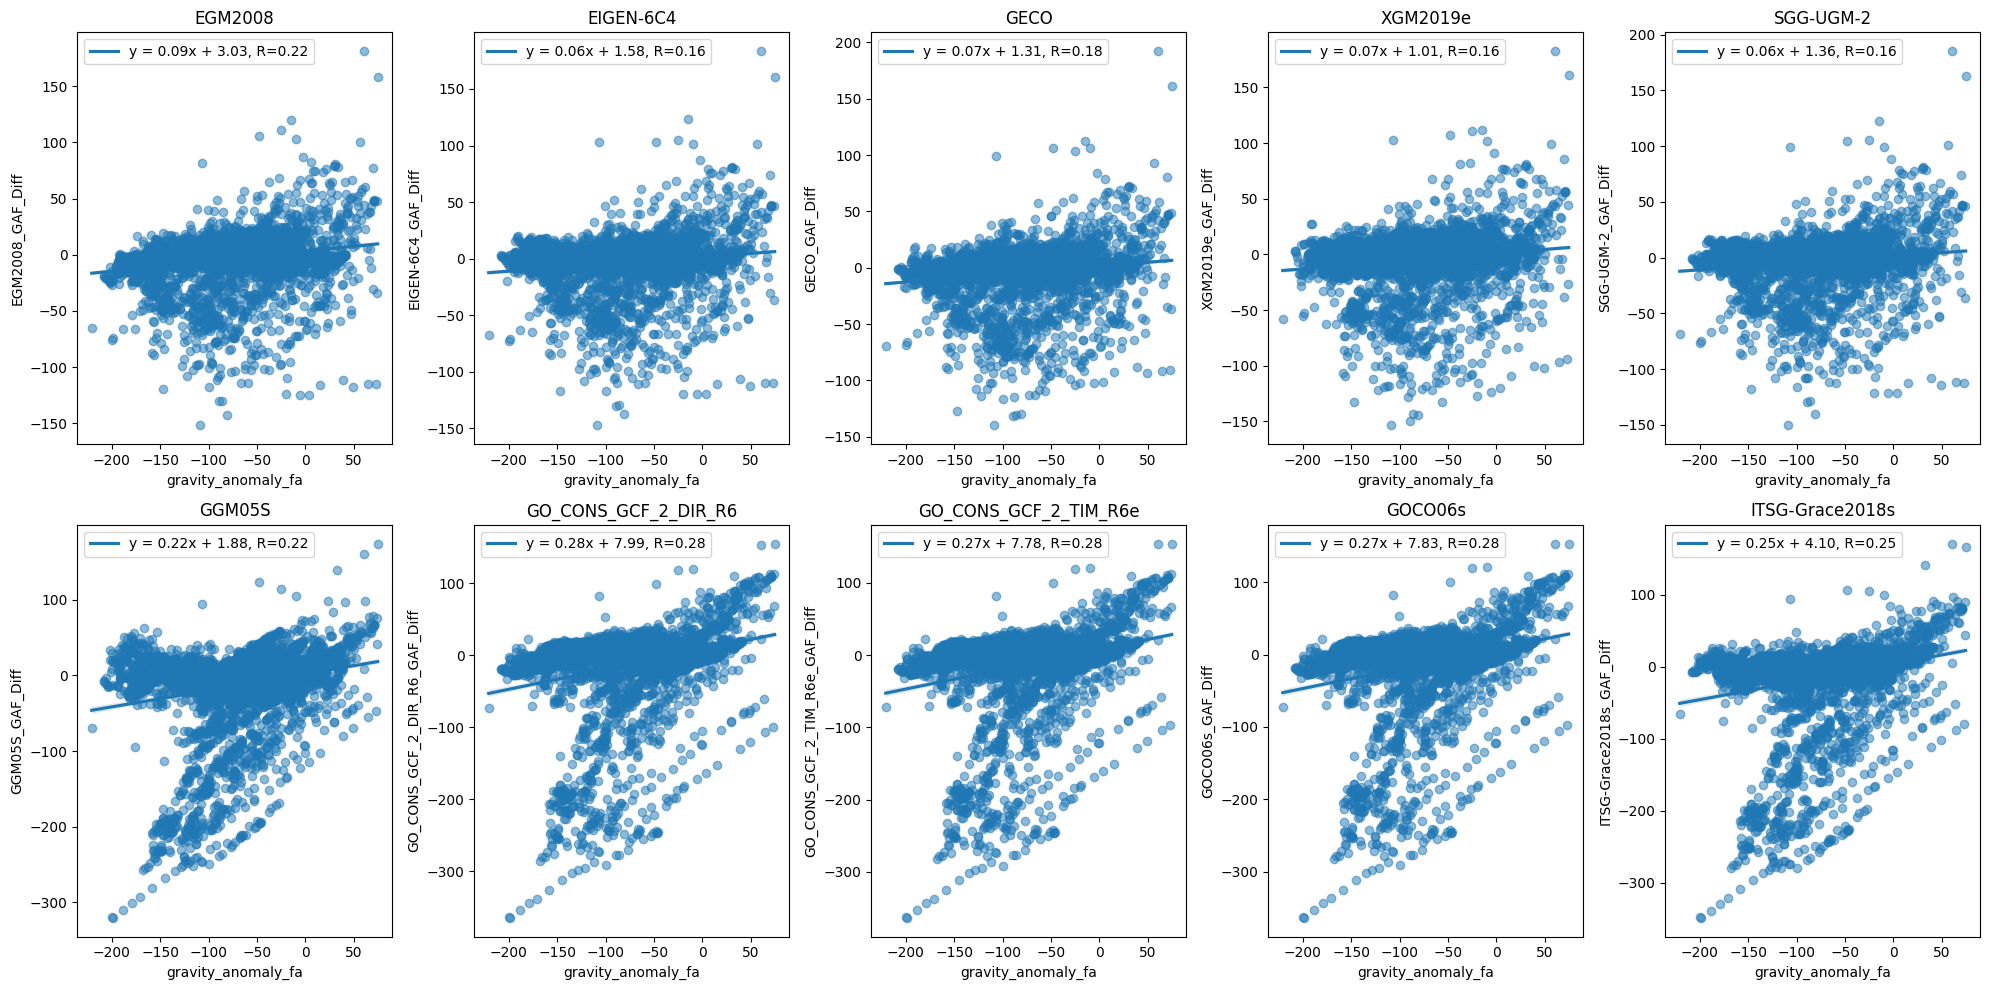

In [ ]:
# Scatter Plots with Regression Lines
plt.figure(figsize=(20, 10))
for i, col in enumerate(df_ggm_diffs.columns[3:]):
    plt.subplot(2, 5, i + 1)
    slope, intercept, r_value, p_value, std_err = stats.linregress(df_ggm_diffs['gravity_anomaly_fa'], df_ggm_diffs[col])
    sns.regplot(x='gravity_anomaly_fa', y=col, data=df_ggm_diffs, line_kws={'label': f"y = {slope:.2f}x + {intercept:.2f}, R={r_value:.2f}"}, scatter_kws={'alpha': 0.5})
    plt.title(col.replace("_GAF_Diff", ""))
    plt.legend()
plt.tight_layout()
plt.show()